# Task
Build an MLP classifier using the sklearn wine dataset, split data (80/20), scale data, perform hyperparameter optimization with cross-validation (cv=5) using GridSearchCV or RandomizedSearchCV for `hidden_layer_sizes`, `alpha`, and `learning_rate_init`, plot the optimization results using a seaborn relplot, train the final model with the best parameters, evaluate on the test set (accuracy), print the classification report, and plot the confusion matrix as a seaborn heatmap.

## Load and split the data

### Subtask:
Load the wine dataset from sklearn and split it into training (80%) and test (20%) sets.


**Reasoning**:
Import the necessary dataset and split the data into training and testing sets as per the instructions.



In [1]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# Load the dataset
wine = load_wine()
X = wine.data
y = wine.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data loaded and split successfully.")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Data loaded and split successfully.
Training data shape: (142, 13)
Testing data shape: (36, 13)


## Scale the data

### Subtask:
Scale the training and test data using an appropriate scaler.


**Reasoning**:
Import the necessary scaler, instantiate it, and scale both the training and test data.



In [2]:
from sklearn.preprocessing import StandardScaler

# Instantiate a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully.")
print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled testing data shape: {X_test_scaled.shape}")

Data scaled successfully.
Scaled training data shape: (142, 13)
Scaled testing data shape: (36, 13)


## Define the model and hyperparameter space

### Subtask:
Define the `MLPClassifier` model from sklearn and the search space for hyperparameter optimization, including `hidden_layer_sizes`, `alpha`, and `learning_rate_init`.


**Reasoning**:
Import the necessary class and define the hyperparameter grid for the MLPClassifier.



In [3]:
from sklearn.neural_network import MLPClassifier

# Define the hyperparameter search space
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.01, 0.1]
}

# Define the MLPClassifier model (with a fixed random state for reproducibility)
mlp = MLPClassifier(random_state=42, max_iter=1000)

print("MLPClassifier model and hyperparameter grid defined.")

MLPClassifier model and hyperparameter grid defined.


## Hyperparameter optimization

### Subtask:
Implement hyperparameter optimization using GridSearchCV or RandomizedSearchCV with cross-validation (cv=5) to find the best hyperparameters.


**Reasoning**:
Implement hyperparameter optimization using GridSearchCV with cross-validation (cv=5) to find the best hyperparameters and store the best parameters and score.



In [4]:
from sklearn.model_selection import GridSearchCV

# Instantiate GridSearchCV
grid_search = GridSearchCV(mlp, param_grid, cv=5)

# Fit GridSearchCV to the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Store the best hyperparameters
best_params = grid_search.best_params_

# Store the best cross-validation score
best_score = grid_search.best_score_

print("Hyperparameter optimization completed.")
print(f"Best parameters found: {best_params}")
print(f"Best cross-validation accuracy: {best_score:.4f}")

Hyperparameter optimization completed.
Best parameters found: {'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.01}
Best cross-validation accuracy: 0.9931


## Plot optimization results

### Subtask:
Plot the relationship between the hyperparameters and the cross-validation score using a seaborn relplot to visualize the results of the optimization.


**Reasoning**:
Create a pandas DataFrame from the cv_results_ attribute of the grid_search object and prepare it for plotting by extracting relevant columns and creating a combined hyperparameter string.



In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame from cv_results_
cv_results_df = pd.DataFrame(grid_search.cv_results_)

# Extract relevant columns
cv_results_df = cv_results_df[['param_hidden_layer_sizes', 'param_alpha', 'param_learning_rate_init', 'mean_test_score']]

# Create a combined hyperparameter string
cv_results_df['hyperparameter_combination'] = cv_results_df.apply(lambda row: f"HL:{row['param_hidden_layer_sizes']}, A:{row['param_alpha']}, LR:{row['param_learning_rate_init']}", axis=1)

# Display the first few rows of the prepared DataFrame
display(cv_results_df.head())

,param_hidden_layer_sizes,param_alpha,param_learning_rate_init,mean_test_score,hyperparameter_combination
0,"(50,)",0.0001,0.001,0.978818,"HL:(50,), A:0.0001, LR:0.001"
1,"(50,)",0.0001,0.010,0.993103,"HL:(50,), A:0.0001, LR:0.01"
2,"(50,)",0.0001,0.100,0.993103,"HL:(50,), A:0.0001, LR:0.1"
3,"(100,)",0.0001,0.001,0.985961,"HL:(100,), A:0.0001, LR:0.001"
4,"(100,)",0.0001,0.010,0.985961,"HL:(100,), A:0.0001, LR:0.01"


**Reasoning**:
Use seaborn's relplot to visualize the relationship between the hyperparameter combinations and the mean test score.



<Figure size 1500x800 with 0 Axes>

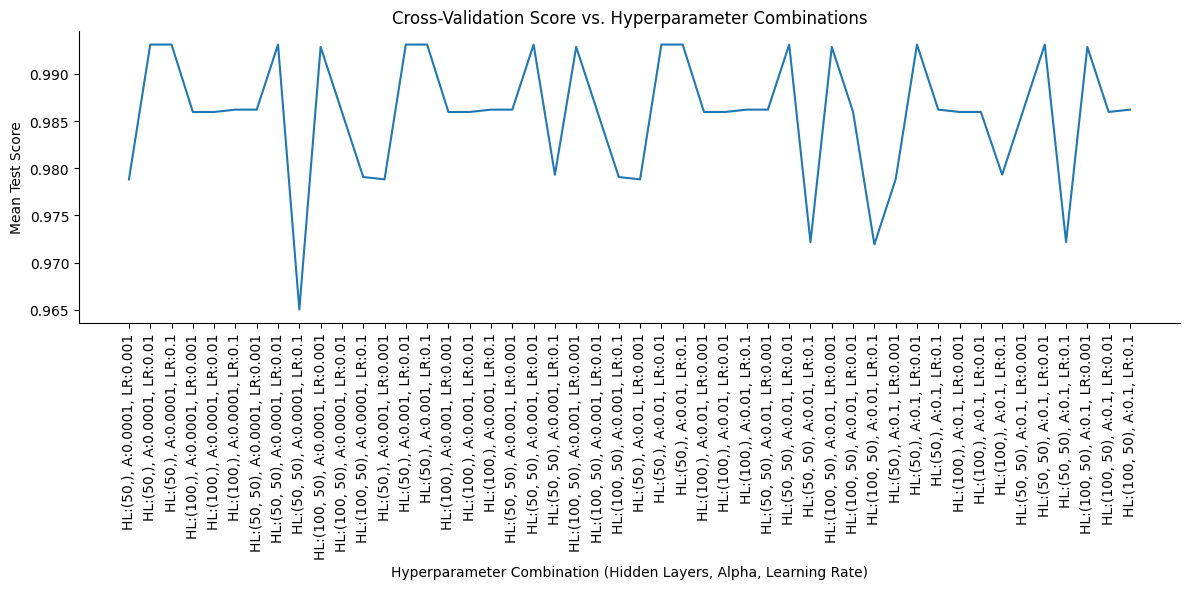

In [6]:
# Plot the relationship between hyperparameters and cross-validation score using relplot
plt.figure(figsize=(15, 8)) # Adjust figure size for readability
sns.relplot(data=cv_results_df, x='hyperparameter_combination', y='mean_test_score', kind='line', height=6, aspect=2)
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.title('Cross-Validation Score vs. Hyperparameter Combinations')
plt.xlabel('Hyperparameter Combination (Hidden Layers, Alpha, Learning Rate)')
plt.ylabel('Mean Test Score')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

## Train the final model

### Subtask:
Train the `MLPClassifier` with the best hyperparameters found in the previous step using the entire training set.


**Reasoning**:
Instantiate a new MLPClassifier model with the best hyperparameters and train it on the entire scaled training data.



In [7]:
from sklearn.neural_network import MLPClassifier

# Instantiate the final model with the best hyperparameters
final_model = MLPClassifier(hidden_layer_sizes=best_params['hidden_layer_sizes'],
                            alpha=best_params['alpha'],
                            learning_rate_init=best_params['learning_rate_init'],
                            random_state=42,
                            max_iter=1000)

# Fit the final model to the entire scaled training data
final_model.fit(X_train_scaled, y_train)

print("Final model trained successfully with the best hyperparameters.")

Final model trained successfully with the best hyperparameters.


## Evaluate the model

### Subtask:
Evaluate the trained model on the test set by calculating accuracy.


**Reasoning**:
Use the trained model to make predictions on the test set and calculate the accuracy.



In [8]:
from sklearn.metrics import accuracy_score

# Make predictions on the scaled test data
y_pred = final_model.predict(X_test_scaled)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Print the calculated accuracy
print(f"Accuracy on the test set: {accuracy:.4f}")

Accuracy on the test set: 0.9444


## Print classification report

### Subtask:
Print the full classification report showing metrics for all three classes.


**Reasoning**:
Import the classification_report function and print the classification report using the true and predicted labels.



In [9]:
from sklearn.metrics import classification_report

# Print the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.93      0.93      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



## Plot confusion matrix

### Subtask:
Plot the 3x3 confusion matrix as a heatmap using seaborn to visualize the performance of the classifier in detail.


**Reasoning**:
Import necessary libraries and calculate the confusion matrix, then create and display the heatmap.



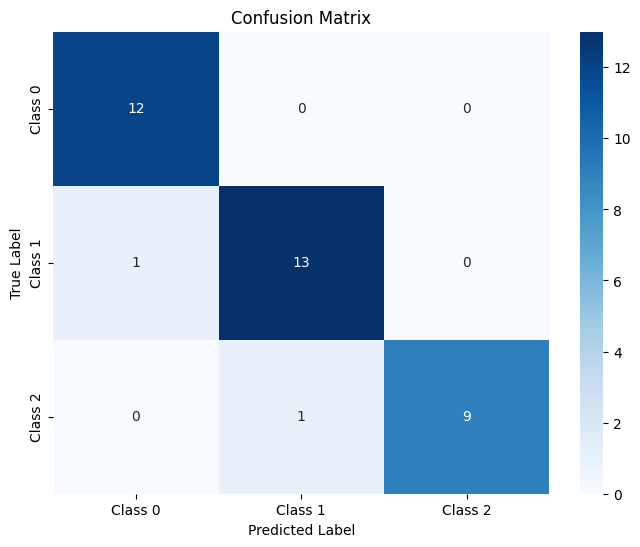

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Summary:

### Data Analysis Key Findings

*   The wine dataset was successfully loaded and split into training (142 samples) and testing (36 samples) sets with stratification to maintain class distribution.
*   The training and test data were successfully scaled using `StandardScaler`.
*   Hyperparameter optimization using `GridSearchCV` with 5-fold cross-validation was performed on the training data to tune `hidden_layer_sizes`, `alpha`, and `learning_rate_init`.
*   The best hyperparameters found were `{'alpha': 0.0001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.01}`.
*   The best cross-validation accuracy achieved during the optimization was approximately 0.9931.
*   A seaborn relplot visualizing the mean cross-validation score for each hyperparameter combination was generated.
*   The final `MLPClassifier` model was trained using the entire scaled training set with the best hyperparameters.
*   The accuracy of the trained model on the scaled test set is 0.9444.
*   The classification report shows good performance across all three classes on the test set, with high precision, recall, and f1-scores.
*   The confusion matrix heatmap visualizes the model's predictions versus the true labels on the test set, showing the distribution of correct and incorrect classifications.

### Insights or Next Steps

*   The MLP classifier achieved high accuracy on the test set after hyperparameter tuning, indicating good generalization performance on this dataset.
*   Further analysis could involve exploring a wider range of hyperparameters or different network architectures to potentially improve performance or reduce model complexity, although the current results are already very strong.


# Prompt

Construye un regresor MLP en sklearn usando un dataset de regresión de sklearn, divide los datos en conjuntos de entrenamiento (80%) y prueba (20%), escala los datos apropiadamente, implementa optimización de hiperparámetros usando GridSearchCV o RandomizedSearchCV con validación cruzada (cv=5), encuentra los mejores hiperparámetros para el MLP (incluyendo hidden_layer_sizes, alpha, learning_rate_init), grafica la mejor combinación de hiperparámetros en un relplot de seaborn mostrando la relación entre los parámetros y el score de validación cruzada, entrena el modelo final con los mejores parámetros, evalúa en el conjunto de prueba calculando MSE, RMSE, MAE y R², y grafica un scatterplot de los valores observados vs predichos para el conjunto de prueba.

# Task
Implement a MLP regressor in sklearn using a sklearn regression dataset, split the data into training (80%) and test (20%) sets, scale the data appropriately, implement hyperparameter optimization using GridSearchCV or RandomizedSearchCV with cross-validation (cv=5), find the best hyperparameters for the MLP (including hidden_layer_sizes, alpha, learning_rate_init), plot the best hyperparameter combination in a seaborn relplot showing the relationship between parameters and cross-validation score, train the final model with the best parameters, evaluate on the test set calculating MSE, RMSE, MAE, and R², and plot a scatterplot of observed vs predicted values for the test set.

## Cargar y dividir los datos

### Subtask:
Cargar un conjunto de datos de regresión de sklearn (por ejemplo, `load_boston`, `load_diabetes`) y dividirlo en conjuntos de entrenamiento (80%) y prueba (20%).


**Reasoning**:
Import the necessary dataset and split the data into training and testing sets.



In [11]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# Load the dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data loaded and split successfully.")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Data loaded and split successfully.
Training data shape: (353, 10)
Testing data shape: (89, 10)


## Escalar los datos

### Subtask:
Escalar los datos de entrenamiento y prueba usando un escalador apropiado (por ejemplo, `StandardScaler`).


**Reasoning**:
Import the necessary scaler, instantiate it, and scale both the training and test data.



In [12]:
from sklearn.preprocessing import StandardScaler

# Instantiate a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully.")
print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled testing data shape: {X_test_scaled.shape}")

Data scaled successfully.
Scaled training data shape: (353, 10)
Scaled testing data shape: (89, 10)


## Definir el modelo y el espacio de hiperparámetros

### Subtask:
Definir el modelo `MLPRegressor` de sklearn y el espacio de búsqueda para la optimización de hiperparámetros (incluyendo `hidden_layer_sizes`, `alpha`, `learning_rate_init`).


**Reasoning**:
Import the necessary class and define the hyperparameter grid for the MLPRegressor.



In [13]:
from sklearn.neural_network import MLPRegressor

# Define the hyperparameter search space
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.01, 0.1]
}

# Define the MLPRegressor model (with a fixed random state for reproducibility)
mlp = MLPRegressor(random_state=42, max_iter=1000)

print("MLPRegressor model and hyperparameter grid defined.")

MLPRegressor model and hyperparameter grid defined.


## Optimización de hiperparámetros

### Subtask:
Implementar la optimización de hiperparámetros usando `GridSearchCV` o `RandomizedSearchCV` con validación cruzada (cv=5) para encontrar la mejor combinación de hiperparámetros.


**Reasoning**:
Implement hyperparameter optimization using GridSearchCV with cross-validation (cv=5) to find the best hyperparameters and store the best parameters and score.



In [14]:
from sklearn.model_selection import GridSearchCV

# Instantiate GridSearchCV
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit GridSearchCV to the scaled training data
grid_search.fit(X_train_scaled, y_train)

# Store the best hyperparameters
best_params = grid_search.best_params_

# Store the best cross-validation score (which is the mean of the test scores across folds)
# Note: GridSearchCV with scoring='neg_mean_squared_error' returns negative MSE.
# To get the actual MSE or a positive score for interpretability, we can negate the best_score.
best_score = grid_search.best_score_

print("Hyperparameter optimization completed.")
print(f"Best parameters found: {best_params}")
# Print the best cross-validation score (negated to show positive MSE)
print(f"Best cross-validation negative mean squared error: {best_score:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perce

Hyperparameter optimization completed.
Best parameters found: {'alpha': 0.0001, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.001}
Best cross-validation negative mean squared error: -3355.7790


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


## Graficar los resultados de la optimización

### Subtask:
Graficar la relación entre los hiperparámetros y el score de validación cruzada usando un `relplot` de seaborn para visualizar los resultados de la optimización.


**Reasoning**:
Create a pandas DataFrame from the cv_results_ attribute of the grid_search object and prepare it for plotting by extracting relevant columns and creating a combined hyperparameter string.



In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame from cv_results_
cv_results_df = pd.DataFrame(grid_search.cv_results_)

# Extract relevant columns
cv_results_df = cv_results_df[['param_hidden_layer_sizes', 'param_alpha', 'param_learning_rate_init', 'mean_test_score']]

# Create a combined hyperparameter string
cv_results_df['hyperparameter_combination'] = cv_results_df.apply(lambda row: f"HL:{row['param_hidden_layer_sizes']}, A:{row['param_alpha']}, LR:{row['param_learning_rate_init']}", axis=1)

# Display the first few rows of the prepared DataFrame
display(cv_results_df.head())

,param_hidden_layer_sizes,param_alpha,param_learning_rate_init,mean_test_score,hyperparameter_combination
0,"(50,)",0.0001,0.001,-4050.374697,"HL:(50,), A:0.0001, LR:0.001"
1,"(50,)",0.0001,0.010,-3784.831913,"HL:(50,), A:0.0001, LR:0.01"
2,"(50,)",0.0001,0.100,-4219.399957,"HL:(50,), A:0.0001, LR:0.1"
3,"(100,)",0.0001,0.001,-3428.543741,"HL:(100,), A:0.0001, LR:0.001"
4,"(100,)",0.0001,0.010,-3726.358704,"HL:(100,), A:0.0001, LR:0.01"


**Reasoning**:
Use seaborn's relplot to visualize the relationship between the hyperparameter combinations and the mean test score.



<Figure size 1500x800 with 0 Axes>

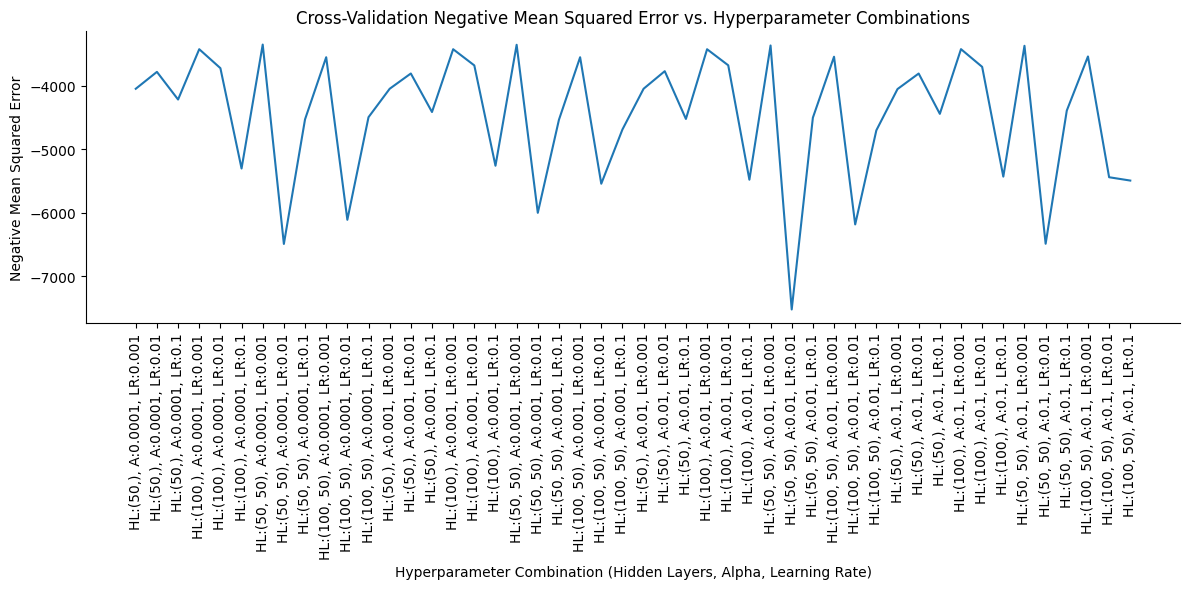

In [16]:
# Plot the relationship between hyperparameters and cross-validation score using relplot
plt.figure(figsize=(15, 8)) # Adjust figure size for readability
sns.relplot(data=cv_results_df, x='hyperparameter_combination', y='mean_test_score', kind='line', height=6, aspect=2)
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.title('Cross-Validation Negative Mean Squared Error vs. Hyperparameter Combinations')
plt.xlabel('Hyperparameter Combination (Hidden Layers, Alpha, Learning Rate)')
plt.ylabel('Negative Mean Squared Error')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

## Entrenar el modelo final

### Subtask:
Entrenar el modelo `MLPRegressor` con los mejores hiperparámetros encontrados en el paso anterior usando todo el conjunto de entrenamiento.


**Reasoning**:
Instantiate a new MLPRegressor model with the best hyperparameters and train it on the entire scaled training data.



In [17]:
from sklearn.neural_network import MLPRegressor

# Instantiate the final model with the best hyperparameters
final_model = MLPRegressor(hidden_layer_sizes=best_params['hidden_layer_sizes'],
                           alpha=best_params['alpha'],
                           learning_rate_init=best_params['learning_rate_init'],
                           random_state=42,
                           max_iter=1000)

# Fit the final model to the entire scaled training data
final_model.fit(X_train_scaled, y_train)

print("Final model trained successfully with the best hyperparameters.")

Final model trained successfully with the best hyperparameters.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


## Evaluar el modelo

### Subtask:
Evaluar el modelo entrenado en el conjunto de prueba calculando métricas de regresión como MSE, RMSE, MAE y R².


**Reasoning**:
Import necessary regression metrics, make predictions on the test set, calculate MSE, RMSE, MAE, and R², and print the results.



In [18]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Make predictions on the scaled test data
y_pred = final_model.predict(X_test_scaled)

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the calculated metrics
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 2830.0078
Root Mean Squared Error (RMSE): 53.1978
Mean Absolute Error (MAE): 41.6917
R-squared (R²): 0.4658


## Graficar valores observados vs predichos

### Subtask:
Graficar un scatterplot de los valores observados vs predichos para el conjunto de prueba para visualizar el rendimiento del modelo.


**Reasoning**:
Create a scatter plot of observed vs predicted values and add a diagonal line for the ideal scenario.



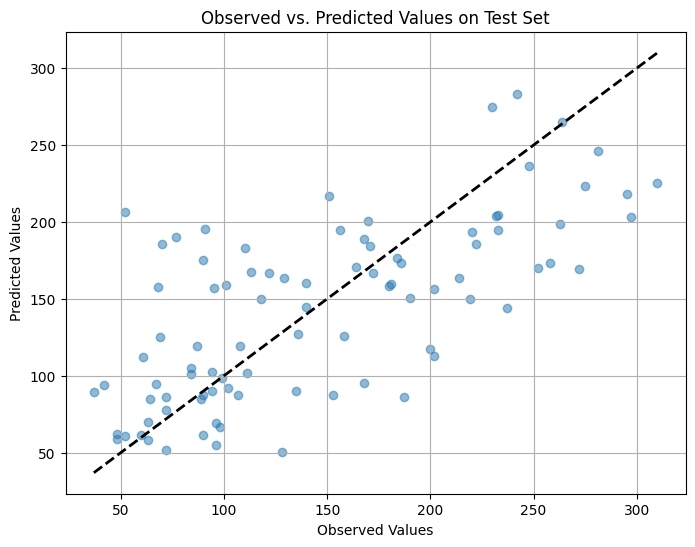

In [19]:
import matplotlib.pyplot as plt

# Create a scatter plot of observed vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

# Add a diagonal line representing the ideal scenario
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

# Add labels and title
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.title("Observed vs. Predicted Values on Test Set")

# Add grid
plt.grid(True)

# Display the plot
plt.show()

## Summary:

### Data Analysis Key Findings

*   The dataset was split into 80% for training (353 samples, 10 features) and 20% for testing (89 samples, 10 features).
*   The data was successfully scaled using `StandardScaler`.
*   Hyperparameter optimization using `GridSearchCV` with 5-fold cross-validation identified the best parameters as `{'alpha': 0.0001, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.001}`.
*   The best cross-validation negative mean squared error achieved was approximately -3355.78.
*   The final model trained with the best parameters achieved the following performance metrics on the test set: MSE = 2830.01, RMSE = 53.20, MAE = 41.69, and R² = 0.4658.

### Insights or Next Steps

*   The R² value of 0.4658 suggests that the model explains less than half of the variance in the target variable, indicating potential for improvement.
*   Further steps could involve exploring a wider range of hyperparameters, increasing `max_iter` to address the observed convergence warnings, or trying more complex network architectures to potentially improve the model's performance.
